In [1]:
!pip install numpy matplotlib ipympl


mambajs 0.19.13

Process pip requirements ...

Requirement numpy already handled by conda/micromamba/mamba.
Requirement matplotlib already handled by conda/micromamba/mamba.
Requirement ipython already satisfied.
Requirement ipywidgets already satisfied.
Requirement matplotlib already satisfied.
Requirement numpy already satisfied.
Requirement pillow already satisfied.
Requirement traitlets already satisfied.


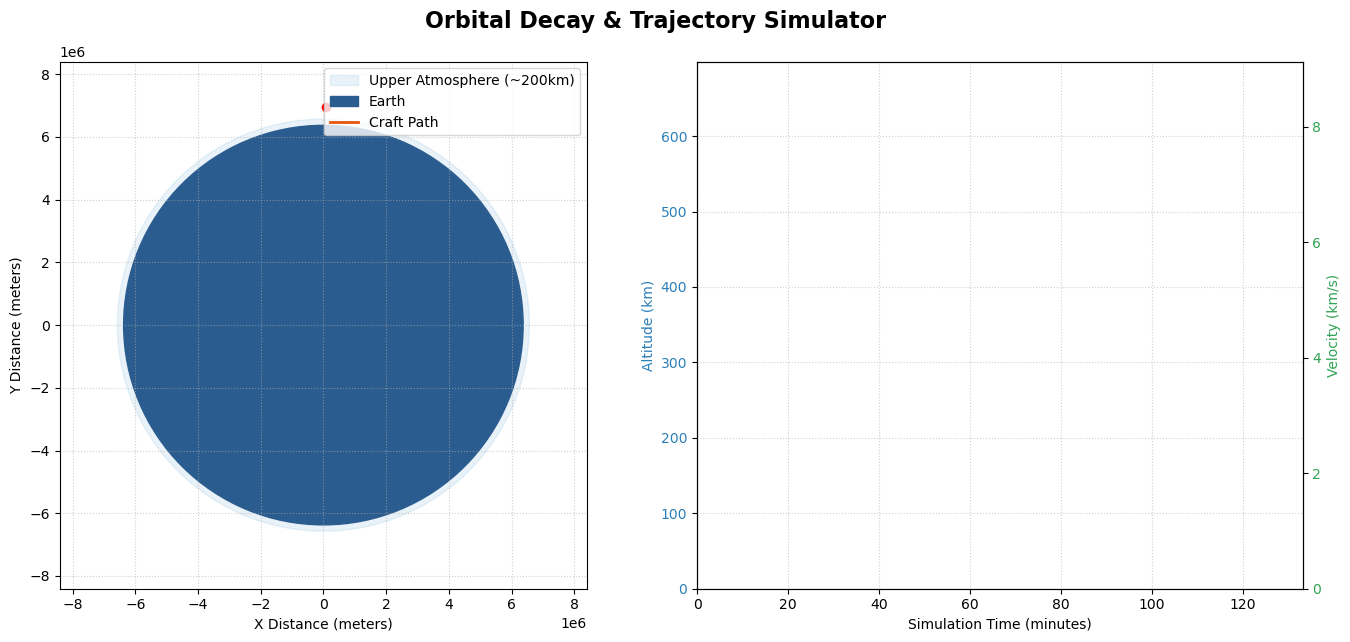

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle

# Enable interactive widgets in Jupyter
%matplotlib inline

# ==========================================
# 1. PHYSICS CONSTANTS & CONFIGURATION
# ==========================================
G = 6.6743e-11          # Gravitational constant (m^3 kg^-1 s^-2)
M_EARTH = 5.972e24      # Mass of Earth (kg)
R_EARTH = 6.371e6       # Radius of Earth (meters)

# Simulation Controls
TIME_STEP = 10          # Seconds per physics frame
TOTAL_FRAMES = 800      # Length of simulation

# ==========================================
# 2. INITIAL CONDITIONS (SPACECRAFT)
# ==========================================
# Position: Start at an altitude of 600 km above Earth's surface
altitude = 600000 
x_start = 0.0
y_start = R_EARTH + altitude

# Velocity: ~7.56 km/s horizontally (just below perfect circular orbit speed)
vx_start = 7560.0
vy_start = 0.0

# Spacecraft Properties
craft_mass = 1000.0     # kg
drag_coeff = 2.2        # Typical satellite drag coefficient
cross_area = 10.0       # Cross-sectional area (m^2)

# ==========================================
# 3. PHYSICS SIMULATION ENGINE
# ==========================================
def get_air_density(alt):
    """Simple exponential atmospheric density model."""
    if alt < 0:
        return 1.2  # Surface density approx
    # Scale height for Earth's atmosphere is roughly 8.5 km
    return 1.2 * np.exp(-alt / 8500.0)

# Arrays to store trajectory history
x_hist = np.zeros(TOTAL_FRAMES)
y_hist = np.zeros(TOTAL_FRAMES)
alt_hist = np.zeros(TOTAL_FRAMES)
vel_hist = np.zeros(TOTAL_FRAMES)

# Initialize state variables
x, y = x_start, y_start
vx, vy = vx_start, vy_start

# Pre-calculate the path
for t in range(TOTAL_FRAMES):
    r = np.sqrt(x**2 + y**2)
    current_alt = r - R_EARTH
    
    # Check for crash/re-entry
    if current_alt <= 0:
        # Fill remaining frames with crash position
        x_hist[t:] = x
        y_hist[t:] = y
        alt_hist[t:] = 0
        vel_hist[t:] = 0
        break
        
    # Calculate Gravitational Acceleration
    acc_g = -G * M_EARTH / (r**3)
    ax_g = acc_g * x
    ay_g = acc_g * y
    
    # Calculate Atmospheric Drag Acceleration
    v_mag = np.sqrt(vx**2 + vy**2)
    rho = get_air_density(current_alt) if current_alt < 300000 else 0.0 # Significant drag below 300km
    
    # Drag force equation: Fd = 0.5 * rho * v^2 * Cd * A
    f_drag = 0.5 * rho * (v_mag**2) * drag_coeff * cross_area
    ax_d = -(f_drag / craft_mass) * (vx / v_mag) if v_mag > 0 else 0
    ay_d = -(f_drag / craft_mass) * (vy / v_mag) if v_mag > 0 else 0
    
    # Net Acceleration
    ax = ax_g + ax_d
    ay = ay_g + ay_d
    
    # Update Velocity (Euler-Cromer integration)
    vx += ax * TIME_STEP
    vy += ay * TIME_STEP
    
    # Update Position
    x += vx * TIME_STEP
    y += vy * TIME_STEP
    
    # Store records
    x_hist[t] = x
    y_hist[t] = y
    alt_hist[t] = current_alt / 1000.0  # Convert to km
    vel_hist[t] = v_mag / 1000.0        # Convert to km/s

# ==========================================
# 4. PLOTTING & ANIMATION SETUP
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle("Orbital Decay & Trajectory Simulator", fontsize=16, fontweight='bold')

# Subplot 1: Orbital Visualizer
ax1.set_aspect('equal')
ax1.grid(True, linestyle=':', alpha=0.6)
# Set limits dynamically based on orbit size with extra padding
max_range = max(np.max(np.abs(x_hist)), np.max(np.abs(y_hist))) * 1.2
ax1.set_xlim(-max_range, max_range)
ax1.set_ylim(-max_range, max_range)
ax1.set_xlabel("X Distance (meters)")
ax1.set_ylabel("Y Distance (meters)")

# Draw Earth and Atmosphere ring
earth_disk = Circle((0, 0), R_EARTH, color='#2b5c8f', label='Earth')
atmosphere_disk = Circle((0, 0), R_EARTH + 200000, color='#6baed6', alpha=0.15, label='Upper Atmosphere (~200km)')
ax1.add_patch(atmosphere_disk)
ax1.add_patch(earth_disk)

# Plot elements
orbit_line, = ax1.plot([], [], color='#e6550d', lw=2, label='Craft Path')
satellite_dot, = ax1.plot([], [], 'ro', markersize=6)
ax1.legend(loc='upper right')

# Subplot 2: Telemetry Data (Altitude and Speed over time)
time_axis = np.arange(TOTAL_FRAMES) * TIME_STEP / 60.0 # in minutes
ax2.grid(True, linestyle=':', alpha=0.6)
alt_line, = ax2.plot([], [], color='#2c7fb8', lw=2, label='Altitude (km)')
ax2.set_xlabel('Simulation Time (minutes)')
ax2.set_ylabel('Altitude (km)', color='#2c7fb8')
ax2.tick_params(axis='y', labelcolor='#2c7fb8')
ax2.set_xlim(0, time_axis[-1])
ax2.set_ylim(0, np.max(alt_hist) * 1.1)

# Second y-axis for velocity
ax2_vel = ax2.twinx()
vel_line, = ax2_vel.plot([], [], color='#31a354', lw=2, linestyle='--', label='Speed (km/s)')
ax2_vel.set_ylabel('Velocity (km/s)', color='#31a354')
ax2_vel.tick_params(axis='y', labelcolor='#31a354')
ax2_vel.set_ylim(0, np.max(vel_hist) * 1.2)

# ==========================================
# 5. ANIMATION LOOP FUNCTION
# ==========================================
def update(frame):
    # If the satellite crashed before this frame, keep drawing last state
    current_x = x_hist[:frame+1]
    current_y = y_hist[:frame+1]
    
    # Update orbit path and marker
    orbit_line.set_data(current_x, current_y)
    if frame < len(x_hist):
        satellite_dot.set_data([x_hist[frame]], [y_hist[frame]])
    
    # Update telemetry graph
    alt_line.set_data(time_axis[:frame+1], alt_hist[:frame+1])
    vel_line.set_data(time_axis[:frame+1], vel_hist[:frame+1])
    
    return orbit_line, satellite_dot, alt_line, vel_line

# Run animation
ani = FuncAnimation(fig, update, frames=TOTAL_FRAMES, interval=20, blit=True)
plt.tight_layout()
plt.show()